# PG-RAD compared to others

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['figure.figsize'] = (5, 3)

In [2]:
source_strengths = [100, 250, 500, 1000, 2500, 5000, 10000]
dist = [10,25,50,75,100]

### 3x3 inch NaI(Tl)

In [ ]:
NAME = 'NaI_3inch'

# 50m from road
pg_rad_ss_max_cps = [3.46, 8.65, 17.29, 34.59, 86.47, 172.94, 345.88]
robert_ss_max_cps = np.array([3.447, 8.616, 17.23, 34.47, 86.16, 172.3, 344.7])
robert_ss_max_cps_unc = np.array([1.856, 2.935, 4.151, 5.871, 9.282, 13.13, 18.56])
alex_ss_max_cps = [3.31, 8.28, 16.56, 33.11, 82.79, 165.58, 331.1]

# 1000 MBq
pg_rad_dist_max_cps = [1266.09, 175.95, 34.59, 12.08, 5.34]
robert_dist_max_cps = np.array([1267, 175.4, 34.47, 12.04, 5.322])
robert_dist_max_cps_unc = np.array([35.59, 13.24, 5.871, 3.470, 2.307])
alex_dist_max_cps = [832.17, 152.99, 33.12, 11.86, 5.29]

### 123% HPGe detector

### 4L NaI(Tl) (R) detector

In [7]:
NAME = 'NaIR'

# 50m from road
pg_rad_ss_max_cps = [43.66,109.15,218.31,436.62,1091.55,2183.10,4366.20]
robert_ss_max_cps = np.array([4.367E+01,1.092E+02,2.183E+02,4.367E+02,1.092E+03,2.183E+03,4.367E+03])
robert_ss_max_cps_unc = np.array([6.608E+00,1.045E+01,1.478E+01,2.090E+01,3.304E+01,4.673E+01,6.608E+01])
alex_ss_max_cps = [35.539267642603946,88.8481691065112,177.69633821301977,355.3926764260448,888.4816910651117,1776.9633821301977,3553.9267642603954]

# 1000 MBq
pg_rad_dist_max_cps = [16033.41,2221.82,436.62,152.52,67.43]
robert_dist_max_cps = np.array([1.605E+04,2.223E+03,4.367E+02,1.525E+02,6.743E+01])
robert_dist_max_cps_unc = np.array([1.250E+02,4.714E+01,2.090E+01,1.235E+01,8.211E+00])
alex_dist_max_cps = [8756.87154459606,1598.2094009020225,345.39391960568605,123.39046111395047,55.02311010332372]

# Plotting

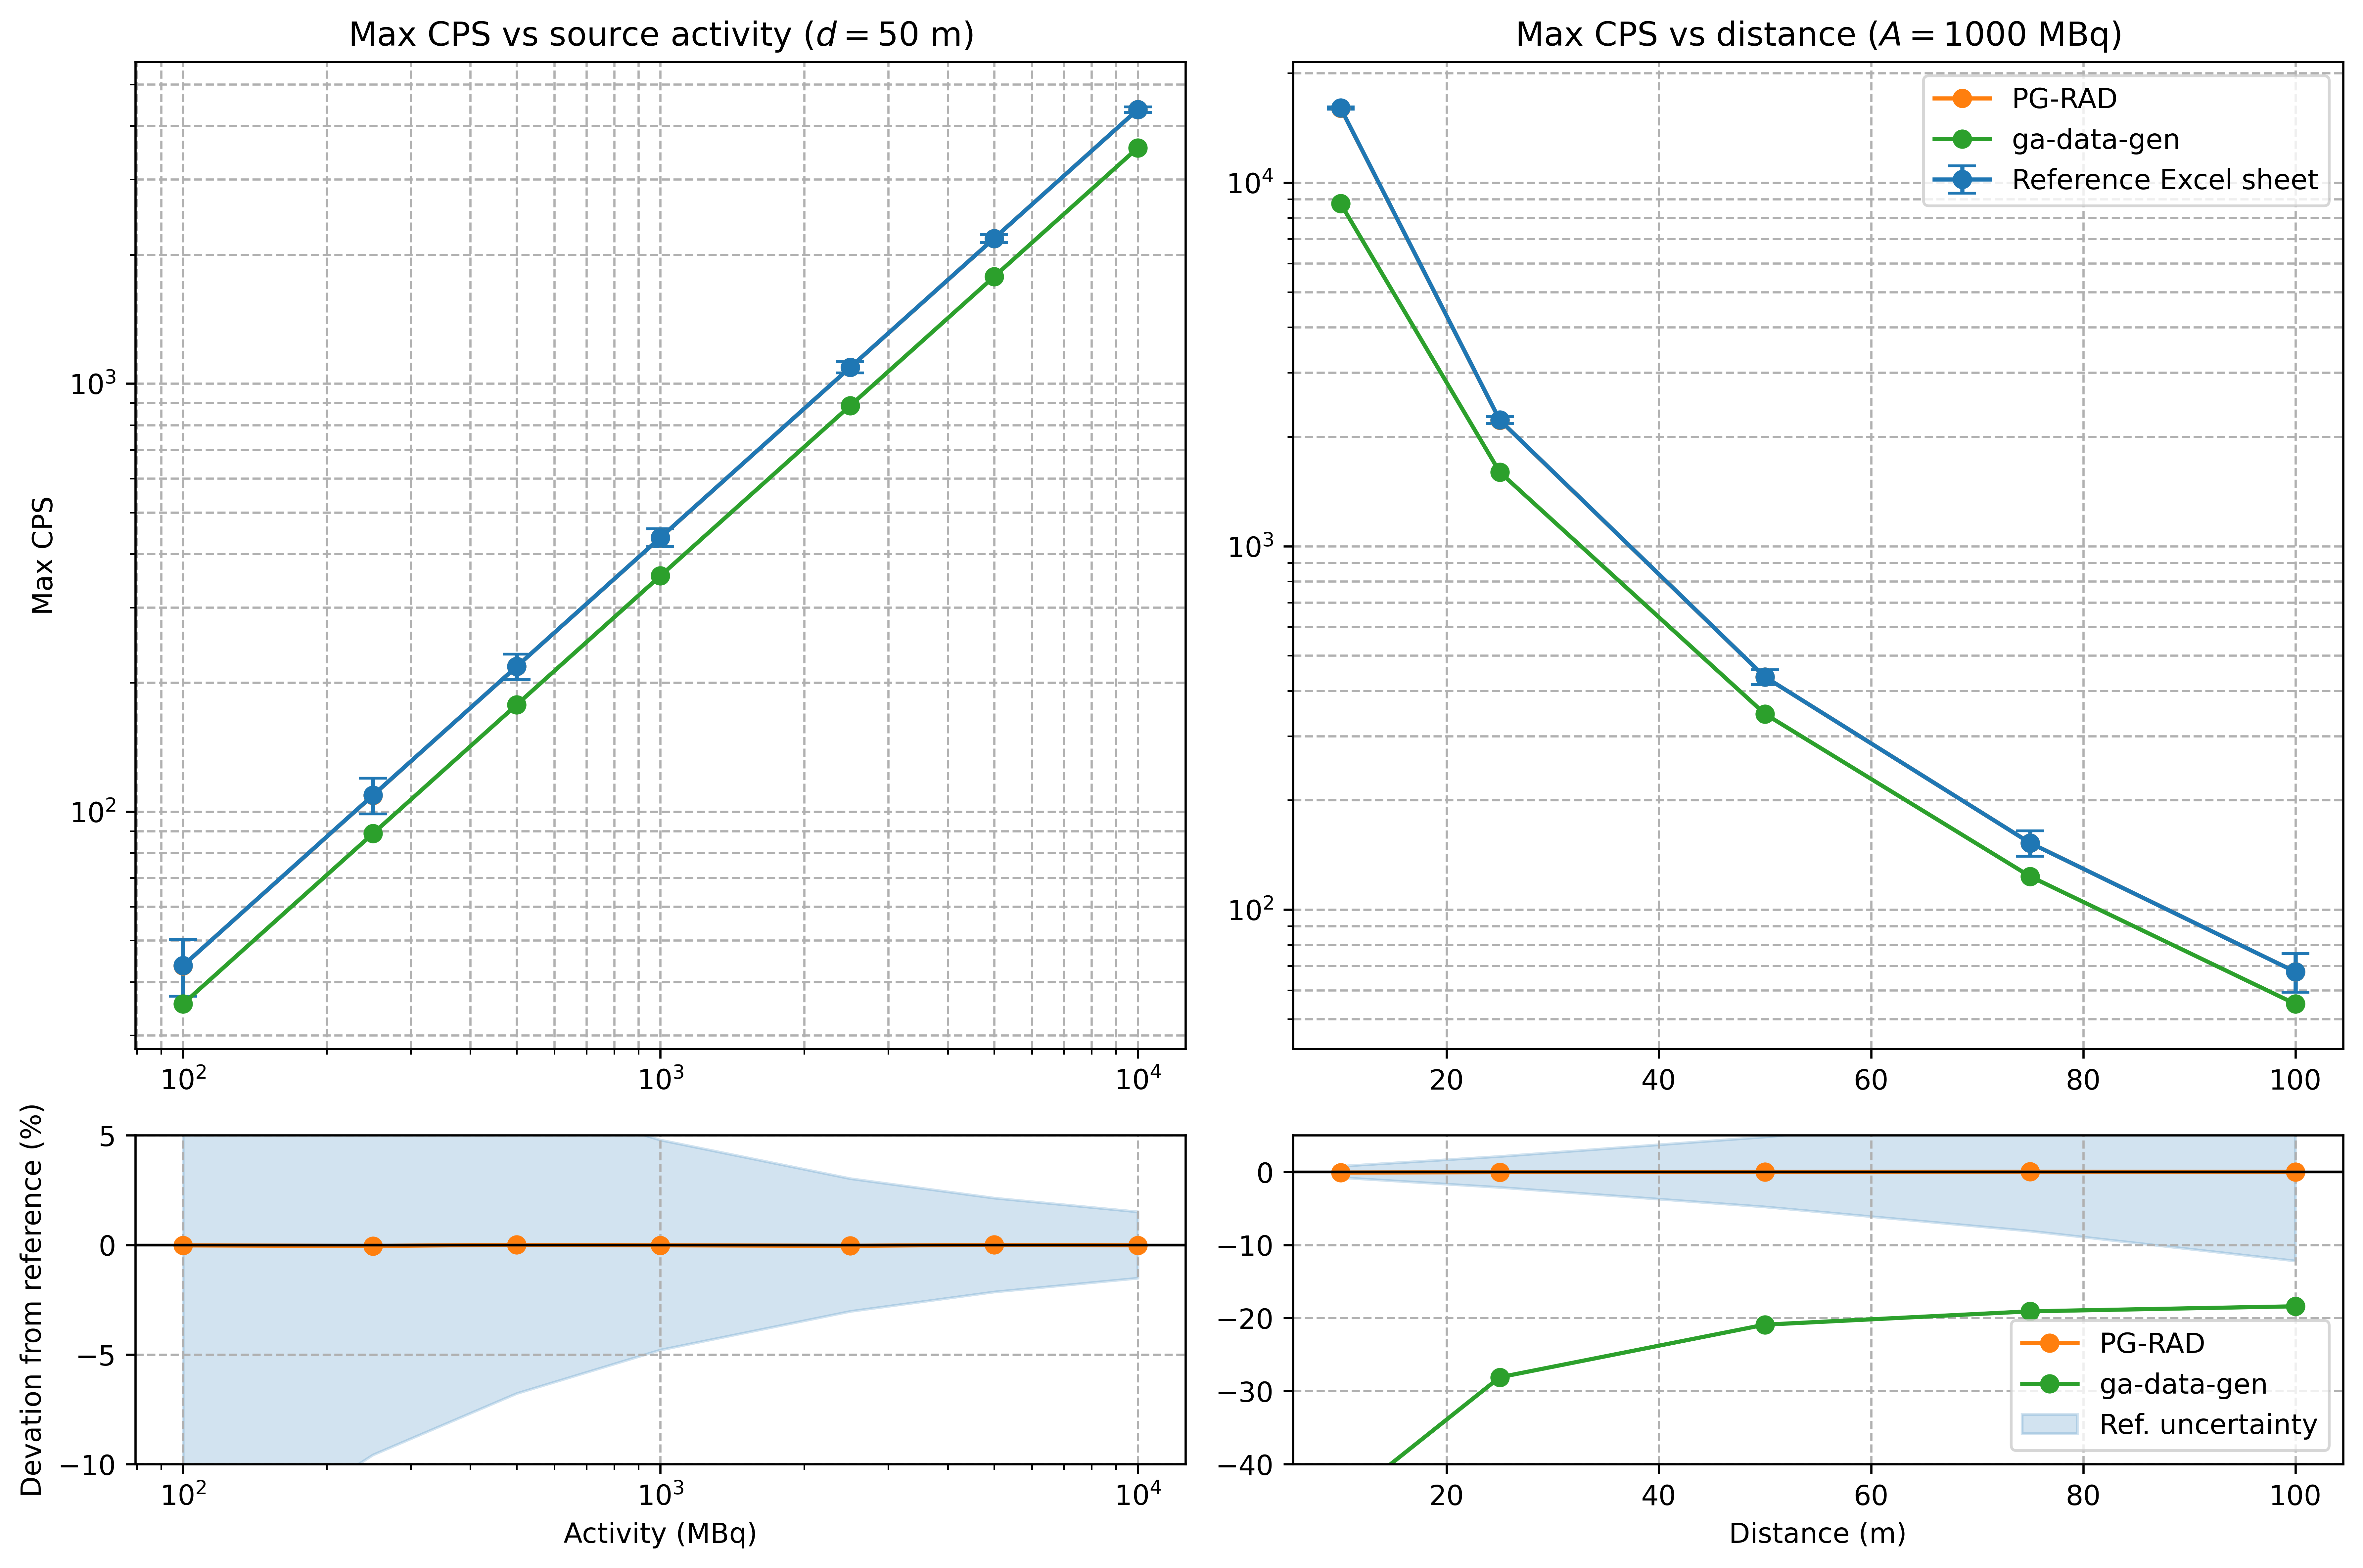

In [8]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(12, 8),
    gridspec_kw={'height_ratios': [3, 1]}  # 75% / 25%
)

# ----------------------
# Plot 1: Source Strengths (original)
# ----------------------
ax1 = axs[0, 0]
ax1.errorbar(source_strengths, robert_ss_max_cps, yerr=robert_ss_max_cps_unc,
             label='Reference Excel sheet', marker='o', capsize=5)
ax1.plot(source_strengths, pg_rad_ss_max_cps, label='PG-RAD', marker='o')
ax1.plot(source_strengths, alex_ss_max_cps, label='ga-data-gen', marker='o')
ax1.set_xscale('log')
ax1.set_yscale('log')
#ax1.set_xlabel('Activity (MBq)')
ax1.set_ylabel('Max CPS')
ax1.set_title('Max CPS vs source activity ($d = 50$ m)')
# ax1.legend()
ax1.grid(True, which="both", ls="--")

# ----------------------
# Plot 2: Distance (original)
# ----------------------
ax2 = axs[0, 1]
ax2.errorbar(dist, robert_dist_max_cps, yerr=robert_dist_max_cps_unc,
             label='Reference Excel sheet', marker='o', capsize=5)
ax2.plot(dist, pg_rad_dist_max_cps, label='PG-RAD', marker='o')
ax2.plot(dist, alex_dist_max_cps, label='ga-data-gen', marker='o')
ax2.set_yscale('log')
#ax2.set_xlabel('Distance (m)')
# ax2.set_ylabel('Max CPS')
ax2.set_title('Max CPS vs distance ($A = 1000$ MBq)')
ax2.legend()
ax2.grid(True, which="both", ls="--")

# ----------------------
# Plot 3: Relative deviation (activity)
# ----------------------
pg_rad_rel_ss = 100 * (pg_rad_ss_max_cps - robert_ss_max_cps) / robert_ss_max_cps
alex_rel_ss   = 100 * (alex_ss_max_cps   - robert_ss_max_cps) / robert_ss_max_cps

robert_ss_rel_unc = 100 * robert_ss_max_cps_unc / robert_ss_max_cps

ax3 = axs[1, 0]
ax3.plot(source_strengths, pg_rad_rel_ss, 'o-', label='PG-RAD', color='tab:orange')
ax3.plot(source_strengths, alex_rel_ss, 'o-', label='ga-data-gen', color='tab:green')
ax3.fill_between(source_strengths, -robert_ss_rel_unc, robert_ss_rel_unc, color='tab:blue', alpha=0.2, label="Ref. uncertainty")

ax3.axhline(0, color='black', linewidth=1)
ax3.set_xscale('log')
ax3.set_xlabel('Activity (MBq)')
ax3.set_ylabel('Devation from reference (%)')
# ax3.set_title('Deviation from Ref. (activity)')
# ax3.legend()
ax3.set_ylim([-10, 5])
ax3.grid(True, ls="--")

# ----------------------
# Plot 4: Relative deviation (distance)
# ----------------------
pg_rad_rel_dist = 100 * (pg_rad_dist_max_cps - robert_dist_max_cps) / robert_dist_max_cps
alex_rel_dist   = 100 * (alex_dist_max_cps   - robert_dist_max_cps) / robert_dist_max_cps

robert_dist_rel_unc = 100 * robert_dist_max_cps_unc / robert_dist_max_cps

ax4 = axs[1, 1]
ax4.plot(dist, pg_rad_rel_dist, 'o-', label='PG-RAD', color='tab:orange')
ax4.plot(dist, alex_rel_dist, 'o-', label='ga-data-gen', color='tab:green')
ax4.fill_between(dist, -robert_dist_rel_unc, robert_dist_rel_unc, color='tab:blue', alpha=0.2, label="Ref. uncertainty")

ax4.axhline(0, color='black', linewidth=1)
ax4.set_xlabel('Distance (m)')
# ax4.set_ylabel('Relative deviation (%)')
# ax4.set_title('Deviation from Ref. (distance)')
ax4.legend()
ax4.grid(True, ls="--")
ax4.set_ylim([-40, 5])
plt.tight_layout()
plt.savefig(f"./plots/pg-rad-comparison_{NAME}.png")